# Demonstração operacional de uma previsão horária

Neste notebook, uma previsão temporal já avaliada é reproduzida como se a decisão estivesse sendo tomada no início de uma hora operacional. O perfil conhecido é apresentado, a demanda real é ocultada, a previsão pontual E0 e o intervalo U4b são disponibilizados, uma capacidade simulada é submetida à regra de decisão e somente depois o valor observado é revelado.


In [1]:
import os
import sys
import warnings

sys.path.insert(0, os.path.abspath('..'))

from matplotlib import pyplot as plt

from src import operational_demo_reports as reports
from src.i18n import make_lang
from src.operational_demo import (
    OperationalDemoConfig,
    build_operational_replay,
)
from src.plotting import set_graph_parameters

warnings.filterwarnings('ignore', category=FutureWarning)
set_graph_parameters()
plt.rcParams['axes.grid'] = False
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

lang = make_lang('pt')


## 1. Objetivo e fronteiras da demonstração

A utilidade prática do sistema preditivo é demonstrada por meio de um replay histórico, e não por uma nova validação. Foi escolhida uma observação OOF de um fold de seleção em condições operacionais normais, já processada pelos Notebooks 06 e 07. Nenhum estimator é reajustado, nenhuma nova previsão é produzida sobre o holdout e nenhuma conclusão confirmatória adicional é extraída.

Como a demanda é agregada para o sistema de Seul, a decisão é expressa em capacidade operacional equivalente, medida em aluguéis por hora. Não pode ser inferido onde as bicicletas deveriam ser posicionadas nem quantas unidades físicas deveriam ser redistribuídas entre estações, pois o dataset não contém estoques ou identificadores geográficos por estação.


In [2]:
reports.environment_report(lang=lang)


,Item,Valor
0,Ambiente conda,Bike-Sharing
1,Interpretador (sys.executable),CONDA_PREFIX\py...
2,Versão do Python,3.10.20
3,Fingerprint do ambiente,8f80d9216d47a792
4,Divergências em relação ao environment.yml,nenhuma
5,Requisitos declarados no modelo,"mlflow==2.10.0, cloudpickle==3.1.2, numpy==1.2..."
6,scikit-learn,1.3.2
7,pandas,2.2.3
8,numpy,1.26.4
9,mlflow,2.10.0


## 2. Contrato do replay operacional

A execução `full` do Notebook 07 é exigida como fonte. São aceitas somente previsões com intervalo disponível, produzidas após o warm-up e pertencentes aos folds `selection`; o regime de stress de 2020 e o holdout final são excluídos por contrato. A semente fixa permite que o exemplo publicado seja reproduzido sem que uma observação favorável seja escolhida manualmente.

A capacidade informada abaixo é hipotética e serve apenas para tornar a saída acionável. Ela não é uma variável observada no dataset e não participa da previsão.


In [3]:
config = OperationalDemoConfig(
    candidate_id='U4b_g0p01',
    coverage=0.90,
    random_state=2026,
    planned_capacity=4000.0,
)
display(reports.protocol_report(config, lang=lang))


,Item,Valor
0,Natureza,replay histórico de uma previsão OOF congelada
1,Uso do holdout final,não utilizado
2,Candidato de incerteza,U4b_g0p01
3,Cobertura nominal,90%
4,Semente do sorteio,2026
5,Capacidade operacional simulada,4.000 aluguéis/hora
6,Reajuste de modelos,nenhum


## 3. Seleção temporal reproduzível

A observação é sorteada entre todas as linhas elegíveis do candidato e da cobertura declarados. O alvo permanece armazenado apenas para a auditoria posterior; ele não é incorporado ao perfil apresentado nem à regra operacional.


In [4]:
replay = build_operational_replay(config)
display(reports.selection_report(replay, lang=lang))


,Item,Valor
0,Timestamp sorteado,22/10/2022 07:00
1,Fold temporal,4
2,Ano meteorológico,2022
3,Linhas elegíveis,34.322
4,Histórico do calibrador,2.160 horas
5,Alpha adaptativo usado,"0,019"


## 4. Perfil conhecido no instante da previsão

São mostradas somente informações que estariam disponíveis no início da hora, incluindo calendário, regime de pico e condições meteorológicas. A demanda observada foi deliberadamente omitida desta etapa.


In [5]:
display(reports.profile_report(replay, lang=lang))


,Item,Valor
0,Data e hora,22/10/2022 07:00
1,Dia da semana,sábado
2,Hora,7
3,Período,fora do pico
4,Estação,outono
5,Chuva,sem chuva
6,Temperatura,10.6 °C
7,Umidade,86%
8,Velocidade do vento,1.8 m/s
9,Visibilidade,795 m


## 5. Previsão pontual e intervalo preditivo

A previsão central foi produzida pelo Champion E0 no respectivo fold temporal e preservada como OOF congelada. Ao redor desse centro, o `U4b_g0p01` foi atualizado prequentialmente apenas com resíduos já observáveis e forneceu o intervalo de 90%, conforme o princípio de adaptação sequencial discutido por Gibbs e Candès (2021).

A cobertura conformal deve ser interpretada como uma garantia empírica marginal ao longo da sequência avaliada. Não é afirmado que exista exatamente 90% de probabilidade de esta observação particular estar dentro do intervalo.


In [6]:
display(reports.forecast_report(replay, lang=lang))


,Item,Valor
0,Previsão pontual E0,1.384 aluguéis/hora
1,Limite inferior de 90%,0 aluguéis/hora
2,Limite superior de 90%,6.732 aluguéis/hora
3,Largura do intervalo,6.732 aluguéis/hora


## 6. Decisão antes da revelação da demanda

A capacidade simulada é comparada primeiro ao limite inferior, depois à previsão central e, por fim, ao limite superior. Quando a capacidade fica entre o ponto e o limite superior, uma zona de atenção é sinalizada e a diferença até o limite superior é apresentada como reserva operacional conservadora.

A decisão é tomada antes que a demanda real seja revelada, reproduzindo a ordem de informação que seria encontrada em operação.


In [7]:
display(reports.decision_report(replay, lang=lang))


,Item,Valor
0,Capacidade operacional simulada,4.000 aluguéis/hora
1,Decisão,ZONA DE ATENÇÃO
2,Capacidade adicional até a previsão central,0 aluguéis/hora
3,Reserva adicional até o limite superior,2.732 aluguéis/hora


## 7. Revelação e auditoria

Somente após o registro da previsão e da decisão é revelada a demanda observada. São verificados o erro do ponto, a cobertura do intervalo e o atendimento do volume realizado pela capacidade simulada. Essa separação impede que a narrativa operacional seja construída retrospectivamente a partir do resultado conhecido.


In [8]:
display(reports.audit_report(replay, lang=lang))


,Item,Valor
0,Demanda posteriormente observada,2.469
1,Erro absoluto da previsão central,1.085
2,Valor real contido no intervalo,sim
3,Capacidade simulada teria atendido a demanda,sim


## 8. Leitura visual da decisão

A previsão central, o intervalo, a capacidade declarada e a demanda posteriormente observada são posicionados na mesma escala. Assim, pode ser distinguido o erro pontual da incerteza operacional que precisaria ser absorvida. A largura e a cobertura são lidas conjuntamente, em conformidade com a avaliação de previsões probabilísticas proposta por Gneiting e Raftery (2007).


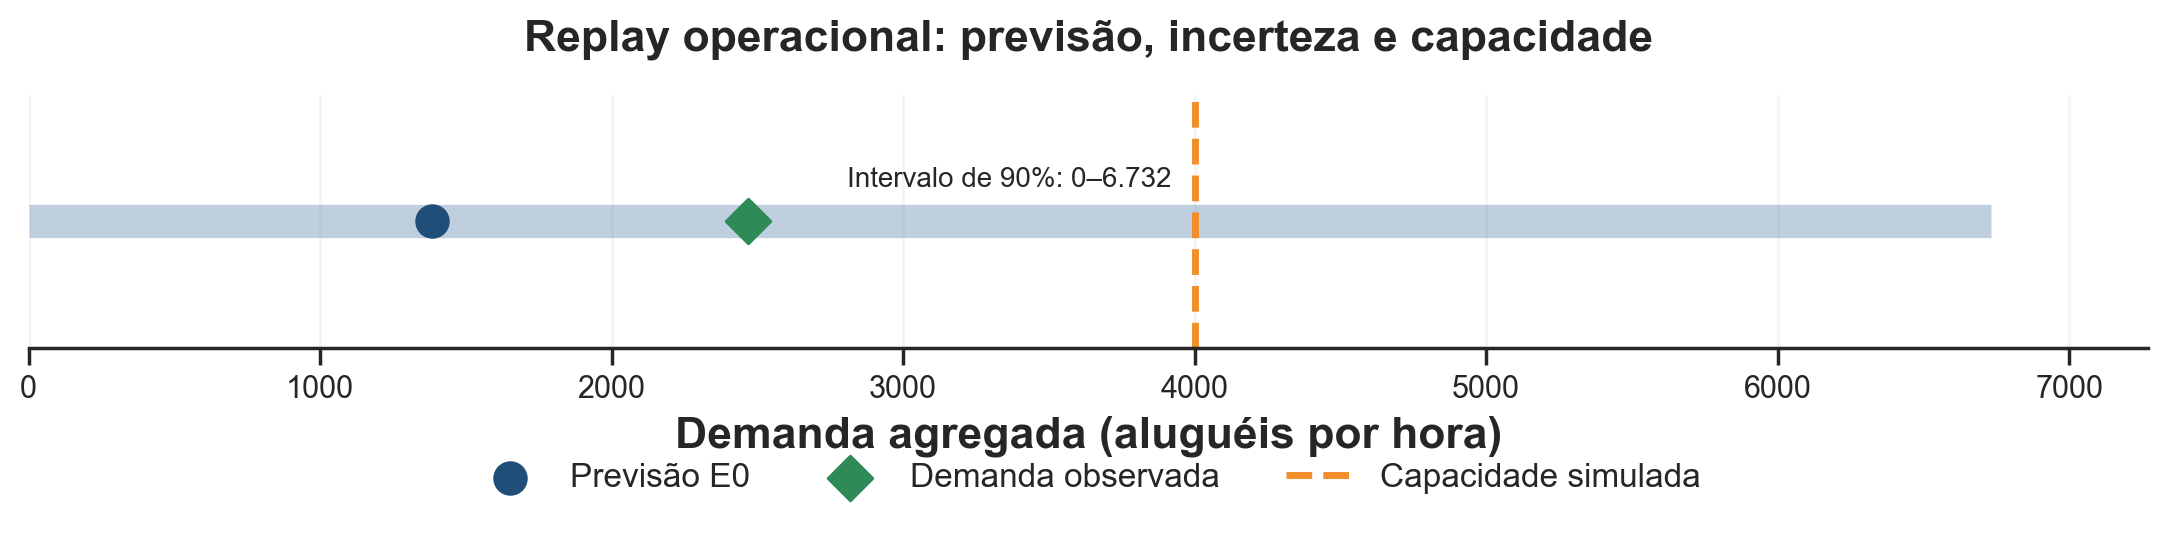

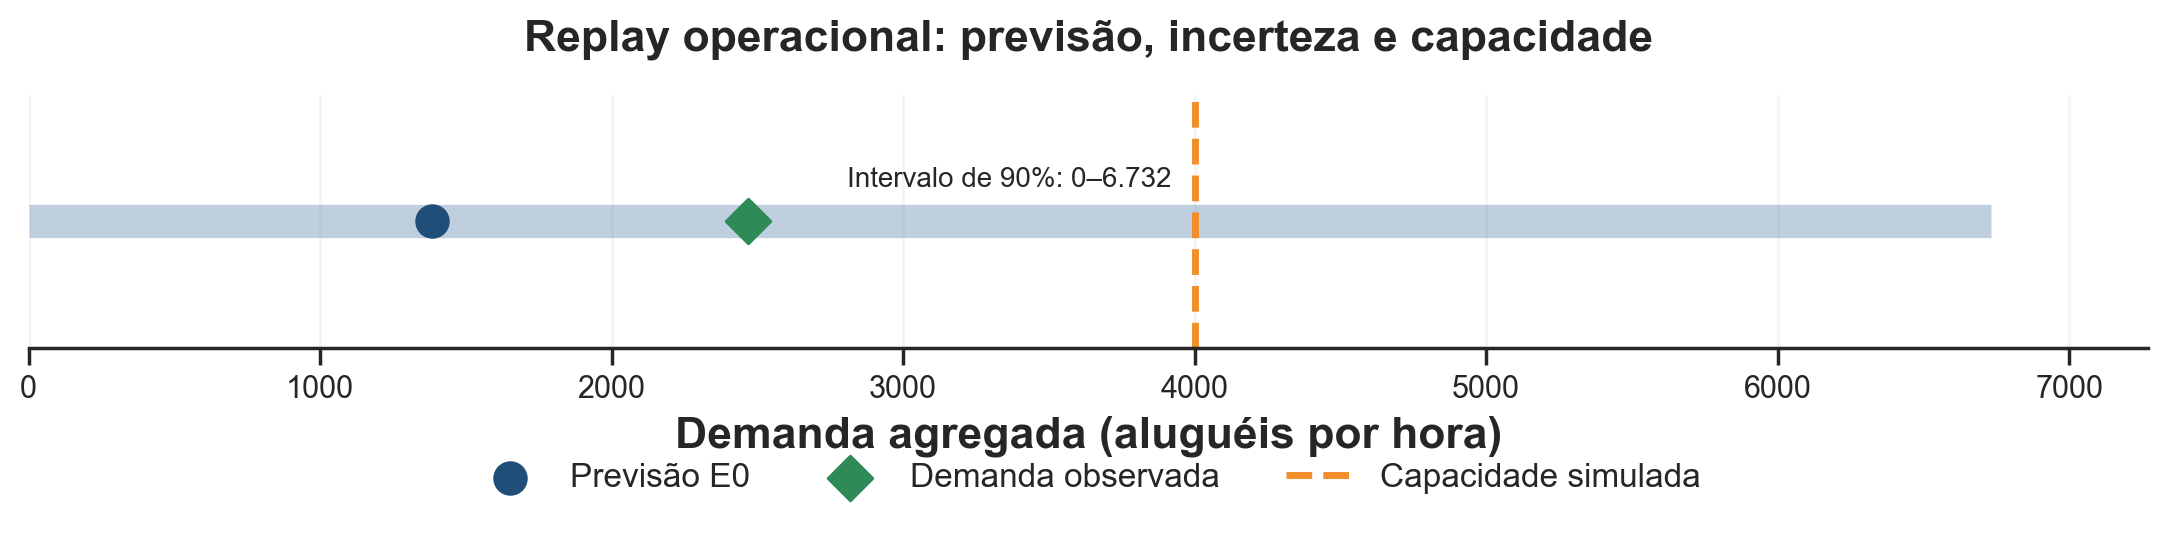

In [9]:
reports.plot_operational_forecast(replay, lang=lang)


### Insights

>Na hora sorteada, correspondente a 22/10/2022 às 07h, foram previstos 1.384 aluguéis pelo E0 e foi produzido pelo U4b o intervalo de 90% entre 0 e 6.732. A capacidade operacional simulada de 4.000 aluguéis/hora superou a previsão central, mas permaneceu 2.732 abaixo do limite superior. Por isso, foi sinalizada uma zona de atenção, em vez de a capacidade ser classificada imediatamente como suficiente.
>
>A demanda de 2.469 aluguéis foi revelada somente após a decisão. O ponto havia subestimado o volume em 1.085 aluguéis, ou 43,9% da demanda realizada, mas o valor real foi contido no intervalo e teria sido atendido pela capacidade simulada. Assim, foi demonstrado que a camada de incerteza comunicou um desvio relevante que a previsão central, isoladamente, não teria mostrado ao responsável pela operação.
>
>A largura de 6.732 aluguéis também deve ser considerada. Embora tenha sido obtida cobertura neste caso, o limite inferior truncado em zero e o limite superior elevado produziram uma recomendação conservadora e potencialmente onerosa. O exemplo confirma a utilidade do intervalo para sinalizar risco, mas também materializa a limitação condicional identificada no Notebook 07: em regimes localmente difíceis, ainda pode ser exigida uma reserva ampla.
>
>A demonstração permanece limitada ao planejamento agregado de aluguéis por hora. Não pode ser derivada uma política de rebalanceamento por estação, e a reserva até o limite superior não deve ser interpretada automaticamente como quantidade física de bicicletas. Para esse avanço, seriam necessários estoques, devoluções, localização das estações e tempos de reposicionamento.


## 9. Síntese

Foi implementada uma demonstração operacional reproduzível sem que a fronteira de validação fosse violada. A observação foi sorteada entre previsões OOF de seleção, o perfil foi apresentado sem o alvo, a capacidade foi declarada como hipótese externa e a decisão foi registrada antes da revelação da demanda.

No exemplo executado, a previsão de 1.384 aluguéis foi confrontada com o intervalo de 0 a 6.732 e com uma capacidade simulada de 4.000 aluguéis/hora. Antes que a demanda fosse conhecida, foi registrada uma zona de atenção e foi quantificada uma reserva conservadora de 2.732 aluguéis/hora. Depois da revelação, verificou-se que a demanda de 2.469 havia sido subestimada pelo ponto em 1.085 aluguéis, mas permanecia dentro do intervalo e abaixo da capacidade simulada.

O valor prático do sistema foi deslocado de uma previsão numérica isolada para uma decisão condicionada à incerteza. Com isso, pode ser estimado não apenas o volume central esperado, mas também o quanto de capacidade adicional seria necessário para alcançar um limite operacional conservador. O ganho não é apresentado como eliminação do risco, mas como explicitação mensurável desse risco. A grande largura observada neste replay também foi preservada na narrativa, pois a cobertura local foi obtida com uma faixa operacionalmente custosa.

A previsão utilizada continua sendo histórica e OOF. Uma inferência realmente online exigiria que o pipeline E0, o produtor de escala E4 e o estado U4b fossem congelados e versionados conjuntamente. Durante as primeiras 168 horas, a previsão pontual poderia ser produzida, mas o intervalo conformal permaneceria indisponível até que o histórico mínimo de resíduos fosse observado.


In [10]:
print(reports.synthesis_report(replay, lang=lang))


Para 22/10/2022 às 07:00, o E0 previu 1.384 aluguéis/hora e o U4b produziu 
o intervalo [0, 6.732]. A capacidade operacional simulada de 
4.000 foi classificada como ZONA DE ATENÇÃO. Depois da revelação, a demanda 
observada de 2.469 foi contida no intervalo e a capacidade simulada teria atendido o volume realizado.


## 10. Proveniência e reprodutibilidade

Os hashes dos artefatos consumidos são apresentados para que o exemplo possa ser associado às previsões conformais e ao dataset que o originaram. A semente, o candidato, a cobertura e a capacidade simulada permanecem declarados na configuração do notebook.


In [11]:
reports.source_audit_report(replay, lang=lang)


,Artefato,Caminho,Bytes,SHA-256
0,conformal_manifest,PROJECT_ROOT/...,11113,bb03d61948651f26f20ceb8c4e76dad648f478e751f1de...
1,conformal_predictions,PROJECT_ROOT/...,73119286,0de496114693c7f7a6f053b365746f8a5230e3553c6772...
2,raw_context,PROJECT_ROOT/...,7410678,62e174f067481a55f8beb4fa44df97cc362be2ef766a57...


### Referência metodológica

Gibbs, I.; Candès, E. J. (2021). Adaptive Conformal Inference Under Distribution Shift. Advances in Neural Information Processing Systems, 34, 1660–1672.

Gneiting, T.; Raftery, A. E. (2007). Strictly Proper Scoring Rules, Prediction, and Estimation. Journal of the American Statistical Association, 102(477), 359–378.
